# 10.3 Distinction Task — Semi-Supervised Learning

#### Step 1 — Imports/indyslld libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.neural_network import MLPClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

## Task 1 — Loads MNIST, splits into 20% labelled, 70% unlabelled, 10% test

#### Code example 1

In [2]:
(X_all, y_all), _ = tf.keras.datasets.mnist.load_data()

# flattens then normalises
X_all = X_all.reshape(len(X_all), -1) / 255.0

# speed subset (10,000 samples)
np.random.seed(28)
idx = np.random.permutation(len(X_all))[:10000]
X_all = X_all[idx]
y_all = y_all[idx]

n = len(X_all)
n_labelled   = int(0.20 * n)  # 20%
n_unlabelled = int(0.70 * n)  # 70%
n_test       = n - n_labelled - n_unlabelled  # 10%

X_labelled   = X_all[:n_labelled]
y_labelled   = y_all[:n_labelled]
X_unlabelled = X_all[n_labelled:n_labelled + n_unlabelled]
y_unlabelled = y_all[n_labelled:n_labelled + n_unlabelled]  # evaluation purposes
X_test       = X_all[n_labelled + n_unlabelled:]
y_test       = y_all[n_labelled + n_unlabelled:]

print('Labelled:   {}'.format(X_labelled.shape[0]))
print('Unlabelled: {}'.format(X_unlabelled.shape[0]))
print('Test:       {}'.format(X_test.shape[0]))

Labelled:   2000
Unlabelled: 7000
Test:       1000


## Task 2 — Selftraining for a feedforward neural set

Trains the MLP using labelled data. Follows this up with high cconfidence pseudo labels from an unlabelled group.

In [3]:
THRESHOLD = 0.95  # conf threshold
MAX_ITER  = 10

X_train = X_labelled.copy()
y_train = y_labelled.copy()
X_unlab = X_unlabelled.copy()

prev_acc = 0
converged = False

for iteration in range(1, MAX_ITER + 1):
    # 1: Train classifier for a labelled set
    clf = MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=42)
    clf.fit(X_train, y_train)

    # 2: predict probability on an unlabelled set
    if len(X_unlab) == 0:
        print('All the unlabelled data was used. Will now stop.')
        break

    probs = clf.predict_proba(X_unlab)
    max_probs = probs.max(axis=1)
    pseudo_labels = clf.predict(X_unlab)

    # what is  highest confidence, select it
    confident_idx = np.where(max_probs >= THRESHOLD)[0]

    # 3: adds pseudo data to for training set
    if len(confident_idx) > 0:
        X_train = np.vstack([X_train, X_unlab[confident_idx]])
        y_train = np.hstack([y_train, pseudo_labels[confident_idx]])
        X_unlab = np.delete(X_unlab, confident_idx, axis=0)

    # 4: Evaluate
    acc = accuracy_score(y_test, clf.predict(X_test))
    print('Iteration {}: pseudo-labels added={}, test accuracy={:.4f}'.format(
        iteration, len(confident_idx), acc))

    # Check convergence
    if len(confident_idx) == 0:
        print('Converged at iteration {}: no new pseudo-labels above threshold.'.format(iteration))
        converged = True
        break

    prev_acc = acc

print('\nFinal self train tests accuracy: {:.4f}'.format(acc))
print(classification_report(y_test, clf.predict(X_test)))

Iteration 1: pseudo-labels added=5775, test accuracy=0.9350
Iteration 2: pseudo-labels added=361, test accuracy=0.9300
Iteration 3: pseudo-labels added=111, test accuracy=0.9350
Iteration 4: pseudo-labels added=60, test accuracy=0.9310
Iteration 5: pseudo-labels added=42, test accuracy=0.9370
Iteration 6: pseudo-labels added=24, test accuracy=0.9370
Iteration 7: pseudo-labels added=18, test accuracy=0.9300
Iteration 8: pseudo-labels added=10, test accuracy=0.9300
Iteration 9: pseudo-labels added=36, test accuracy=0.9310
Iteration 10: pseudo-labels added=13, test accuracy=0.9340

Final self train tests accuracy: 0.9340
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       115
           1       0.95      0.97      0.96       106
           2       0.90      0.89      0.90        93
           3       0.94      0.91      0.92       101
           4       0.95      0.93      0.94       106
           5       0.88      0.91      0.90      

## Task 3 — Label Propagation (second semi-supervised)

Label propagation will use a graph approach in order to spread data from labelled into unlabelled.

In [4]:
# Label Propagation requires -1 for unlabelled
X_lp = np.vstack([X_labelled, X_unlabelled])
y_lp = np.hstack([y_labelled, np.full(len(X_unlabelled), -1)])

lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=1000)
lp.fit(X_lp, y_lp)

lp_acc = accuracy_score(y_test, lp.predict(X_test))
print('Label Propagation accuracy: {:.4f}'.format(lp_acc))
print(classification_report(y_test, lp.predict(X_test)))

print('\nComparison:')
print('Self-Training accuracy:    {:.4f}'.format(acc))
print('Label Propagation accuracy:{:.4f}'.format(lp_acc))

Label Propagation accuracy: 0.9320
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       115
           1       0.88      0.99      0.93       106
           2       1.00      0.90      0.95        93
           3       0.90      0.94      0.92       101
           4       1.00      0.88      0.93       106
           5       0.92      0.90      0.91        89
           6       0.92      0.95      0.93        81
           7       0.94      0.97      0.95       116
           8       0.98      0.89      0.93       106
           9       0.86      0.92      0.89        87

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.94      0.93      0.93      1000


Comparison:
Self-Training accuracy:    0.9340
Label Propagation accuracy:0.9320


## Task 4 — Error analysis for incorrect pseudo labels

completes an analysis of the human error on quant labels for both algos.

In [5]:
# pseudo-label errors for self training
st_pseudo = clf.predict(X_unlabelled)
st_errors = np.where(st_pseudo != y_unlabelled)[0]

print('pseudo-label errors for self training analysis')
print('Total unlabelled: {}'.format(len(y_unlabelled)))
print('Wrong pseudo-labels: {} ({:.1f}%)'.format(
    len(st_errors), 100 * len(st_errors) / len(y_unlabelled)))

# which is most confused pairs
from collections import Counter
st_confusion = Counter(zip(y_unlabelled[st_errors], st_pseudo[st_errors]))
print('\n5 most confused pairs (true, predicted):')
for pair, count in st_confusion.most_common(5):
    print('  {} -> {}: {} times'.format(pair[0], pair[1], count))

pseudo-label errors for self training analysis
Total unlabelled: 7000
Wrong pseudo-labels: 606 (8.7%)

5 most confused pairs (true, predicted):
  3 -> 5: 40 times
  4 -> 9: 23 times
  2 -> 8: 21 times
  9 -> 4: 20 times
  3 -> 8: 20 times


In [6]:
# LabelPropagation using pseudo-label errors
lp_pseudo = lp.transduction_[:len(X_unlabelled)]
lp_errors = np.where(lp_pseudo != y_unlabelled)[0]

print('Label Propagation for Pseudo Error Analysis')
print('Wrong pseudo-labels: {} ({:.1f}%)'.format(
    len(lp_errors), 100 * len(lp_errors) / len(y_unlabelled)))

lp_confusion = Counter(zip(y_unlabelled[lp_errors], lp_pseudo[lp_errors]))
print('\n5 most confused pairs (true, predicted):')
for pair, count in lp_confusion.most_common(5):
    print('  {} -> {}: {} times'.format(pair[0], pair[1], count))

Label Propagation for Pseudo Error Analysis
Wrong pseudo-labels: 6316 (90.2%)

5 most confused pairs (true, predicted):
  9 -> 1: 100 times
  7 -> 1: 97 times
  6 -> 1: 96 times
  4 -> 1: 95 times
  1 -> 9: 94 times


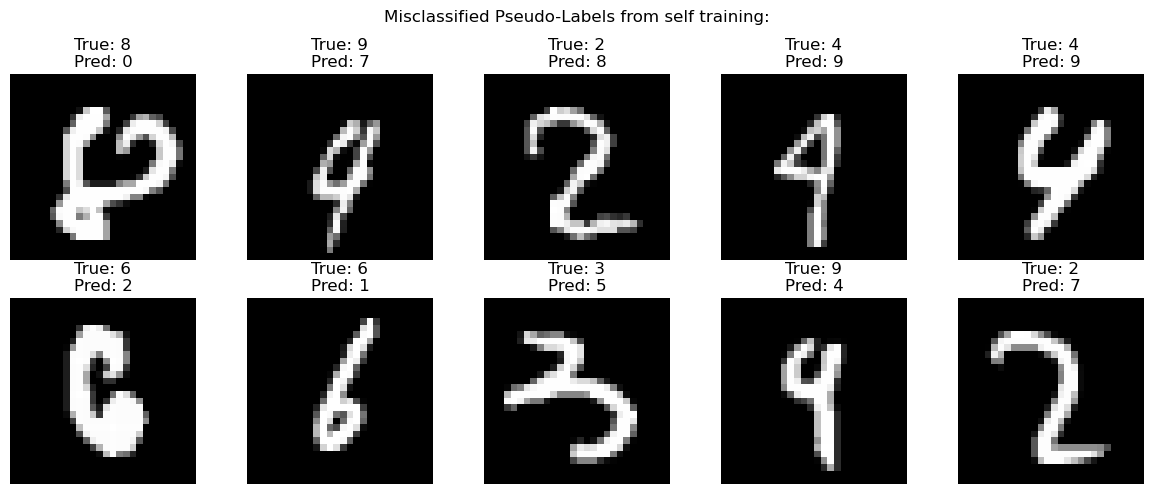

In [7]:
# Human error analysis shows misclassified
X_unlab_img = X_unlabelled[st_errors[:10]].reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_unlab_img[i], cmap='gray')
    ax.set_title('True: {}\nPred: {}'.format(
        y_unlabelled[st_errors[i]], st_pseudo[st_errors[i]]))
    ax.axis('off')
plt.suptitle('Misclassified Pseudo-Labels from self training:')
plt.tight_layout()
plt.show()